<a href="https://colab.research.google.com/github/Muhammad-Ahmad-1341661/deep-learning-models/blob/main/Weekly_Assignment_Completed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Train: (60000, 28, 28), Test: (10000, 28, 28)


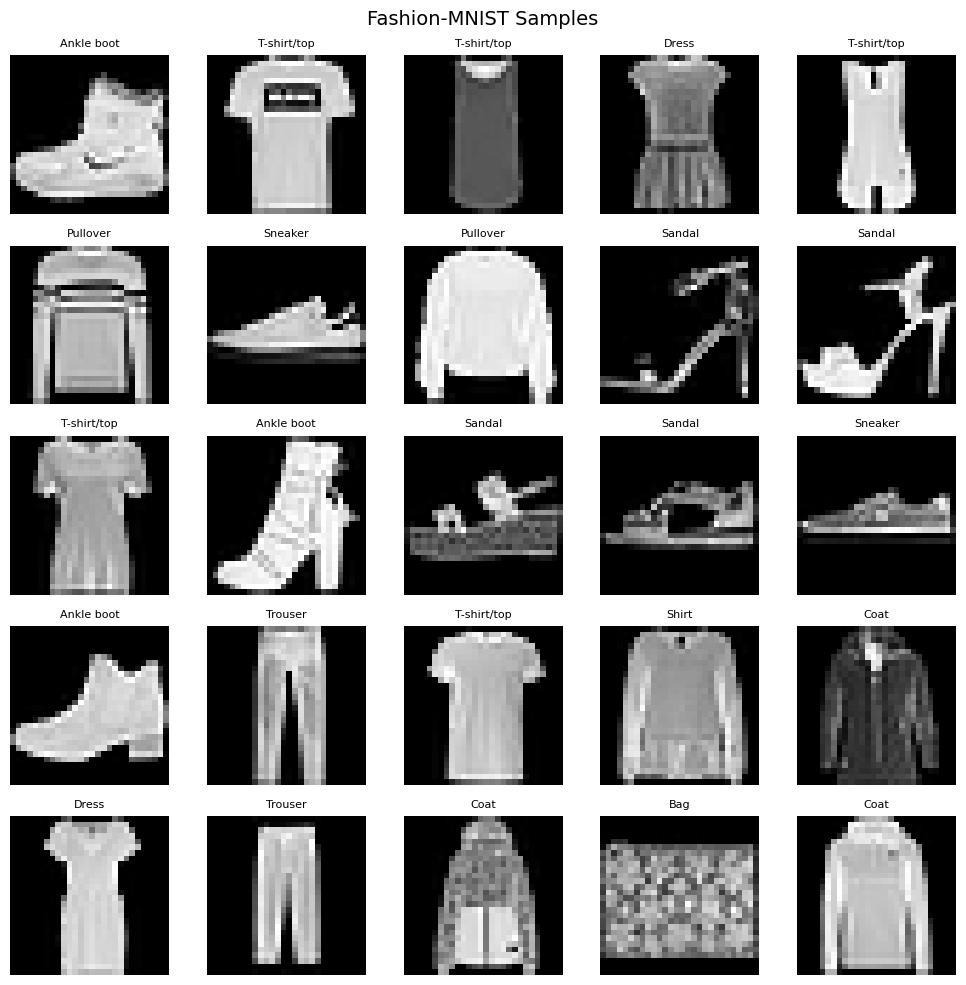

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
import numpy as np

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]], fontsize=8)
    plt.axis('off')
plt.suptitle('Fashion‑MNIST Samples', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32') / 255.0
y_train = y_train.astype(np.int32)
y_test  = y_test.astype(np.int32)
print(f"X_train shape: {X_train.shape}, dtype: {X_train.dtype}")

X_train shape: (60000, 28, 28), dtype: float32


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(512, activation='relu'),
    Dropout(0.6),                     # ✅ 0.3–0.5 ke beech
    Dense(256, activation='relu'),
    Dropout(0.6),
    Dense(128, activation='relu'),
    Dropout(0.6),
    Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_10 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau

model.compile(
    optimizer=Adam(learning_rate=0.0005),   # ✅ 0.001 se kam → zyada stable
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
print("✅ LR=0.0005, ReduceLROnPlateau ready.")

✅ LR=0.0005, ReduceLROnPlateau ready.


In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=40,                # moderate
    batch_size=32,            # standard
    callbacks=[reduce_lr],
    verbose=1
)
print("✅ Training complete.")

Epoch 1/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.6612 - loss: 0.9386 - val_accuracy: 0.8121 - val_loss: 0.5125 - learning_rate: 5.0000e-04
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7906 - loss: 0.6016 - val_accuracy: 0.8259 - val_loss: 0.4675 - learning_rate: 5.0000e-04
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8145 - loss: 0.5355 - val_accuracy: 0.8451 - val_loss: 0.4368 - learning_rate: 5.0000e-04
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8247 - loss: 0.5062 - val_accuracy: 0.8517 - val_loss: 0.4146 - learning_rate: 5.0000e-04
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8295 - loss: 0.4888 - val_accuracy: 0.8548 - val_loss: 0.4059 - learning_rate: 5.0000e-04
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8365 - loss: 0.4711 - val_accuracy: 0.8501 - val_loss: 0.4014 - learning_rate: 5.0000e-04
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/st

Train Accuracy: 0.9145 (91.4%)
Test Accuracy:  0.8886 (88.9%)
Gap:            0.0259 (2.6%)
⚠️ Phir bhi 90% nahi aya – epochs 45 kar ke dekh lo.


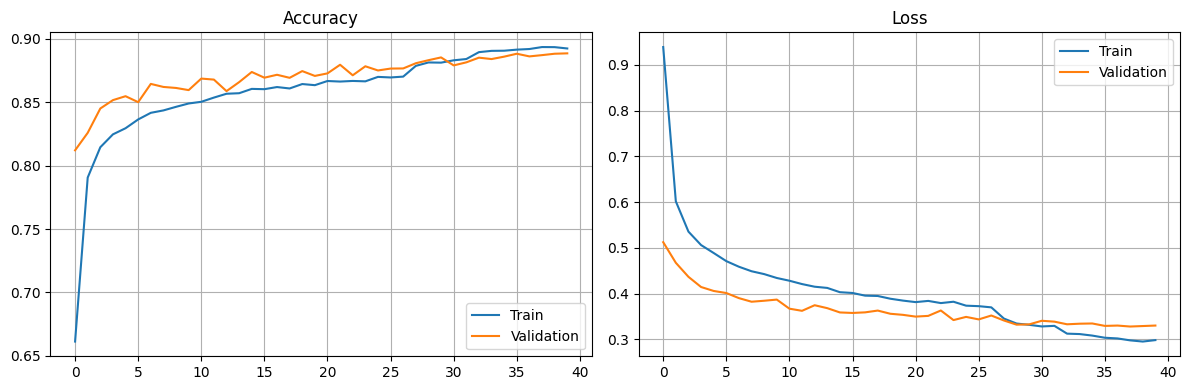

In [ ]:
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc   = model.evaluate(X_test, y_test, verbose=0)
gap = abs(train_acc - test_acc)

print(f"Train Accuracy: {train_acc:.4f} ({train_acc*100:.1f}%)")
print(f"Test Accuracy:  {test_acc:.4f} ({test_acc*100:.1f}%)")
print(f"Gap:            {gap:.4f} ({gap*100:.1f}%)")

if test_acc >= 0.90:
    print("🎉 Teacher ki demand poori – 90%+!")
else:
    print("⚠️ Phir bhi 90% nahi aya – epochs 45 kar ke dekh lo.")

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy'); plt.legend(); plt.grid()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss'); plt.legend(); plt.grid()
plt.tight_layout(); plt.show()

👕 Apni fashion image upload karein (clear, na blur na over‑bright)


Saving images.jfif to images.jfif


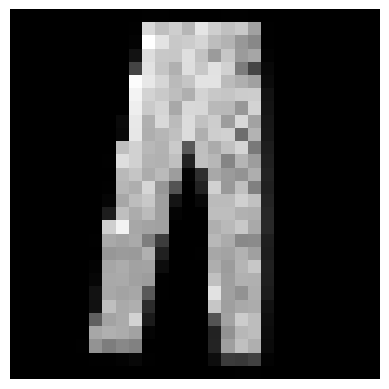


🎯 Predicted: **Trouser** (99.5%)
   T-shirt/top    :   0.0%
   Trouser        :  99.5%
   Pullover       :   0.0%
   Dress          :   0.4%
   Coat           :   0.0%
   Sandal         :   0.0%
   Shirt          :   0.0%
   Sneaker        :   0.0%
   Bag            :   0.0%
   Ankle boot     :   0.0%


In [ ]:
import cv2
from google.colab import files

print("👕 Apni fashion image upload karein (clear, na blur na over‑bright)")
uploaded = files.upload()
fname = list(uploaded.keys())[0]

img = cv2.imread(fname, cv2.IMREAD_GRAYSCALE)
if img is None:
    print("❌ Image read nahi hui.")
else:
    img = cv2.resize(img, (28,28))
    if np.mean(img) > 127:
        img = 255 - img
    img_norm = img.astype('float32') / 255.0

    plt.imshow(img, cmap='gray'); plt.axis('off'); plt.show()

    pred = model.predict(np.expand_dims(img_norm,0), verbose=0)[0]
    pred_class = np.argmax(pred)
    conf = np.max(pred) * 100

    print(f"\n🎯 Predicted: **{class_names[pred_class]}** ({conf:.1f}%)")
    for i in range(10):
        print(f"   {class_names[i]:15s}: {pred[i]*100:5.1f}%")

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/Weekly Assignment Completed'
os.makedirs(save_path, exist_ok=True)

model.save(f'{save_path}/model.keras')
print("✅ Model saved as 'model.keras' in Google Drive at 'Weekly Assignment Completed'.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model saved as 'model.keras' in Google Drive at 'Weekly Assignment Completed'.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model loaded from Drive.
👕 Apni fashion image upload karein


Saving hfd.jfif to hfd (5).jfif


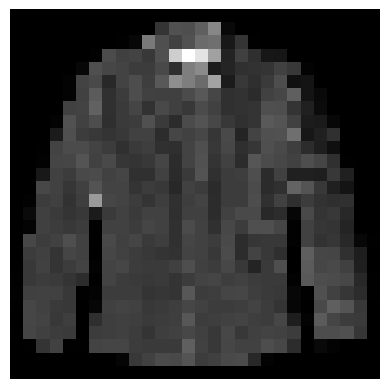


🎯 Predicted: **Shirt** (77.4%)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from google.colab import drive, files
from tensorflow.keras.models import load_model

drive.mount('/content/drive')

model = load_model('/content/drive/MyDrive/Weekly Assignment Completed/model.keras')
print("✅ Model loaded from Drive.")

class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

# Prediction ke liye image upload
print("👕 Apni fashion image upload karein")
uploaded = files.upload()
fname = list(uploaded.keys())[0]
img = cv2.imread(fname, cv2.IMREAD_GRAYSCALE)
if img is not None:
    img = cv2.resize(img, (28,28))
    if np.mean(img) > 127: img = 255 - img
    img_norm = img.astype('float32')/255.0
    plt.imshow(img, cmap='gray'); plt.axis('off'); plt.show()
    pred = model.predict(np.expand_dims(img_norm,0), verbose=0)[0]
    pred_class = np.argmax(pred)
    conf = np.max(pred)*100
    print(f"\n🎯 Predicted: **{class_names[pred_class]}** ({conf:.1f}%)")